# 02 Preprocessing and Exploratory Data Analysis

## Objective
The goal of this notebook is to:
- load the combined raw match-level dataset,
- inspect its structure and quality,
- identify competition phases from round labels,
- keep only **regular season** matches,
- check duplicates and missing values,
- validate outcome and team consistency,
- export a clean regular-season dataset for feature engineering.

## Motivation for filtering
The Czech top division includes:
- a regular season,
- post-season championship / relegation groups,
- and potentially relegation play-off matches involving teams outside the core 16-team league structure.

To ensure a consistent modeling framework, the first version of the project uses **regular season matches only**.

## Input
`data/interim/czech_liga/matches_all_seasons_raw.csv`

## Output
`data/interim/czech_liga/matches_regular_season_clean.csv`

**Project setup**

In [38]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print("Source directory exists:", SRC_DIR.exists())

Project root: C:\Users\cerve\Desktop\DP\football_prediction
Source directory: C:\Users\cerve\Desktop\DP\football_prediction\src
Source directory exists: True


**Imports**

In [39]:
import re
import pandas as pd
import matplotlib.pyplot as plt

from config import SETTINGS, INTERIM_DIR, TABLES_DIR, FIGURES_DIR
from data_io import load_csv, save_csv, ensure_dir

**Display settings**

In [3]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

## 1. Load the combined dataset

We start by loading the raw multi-season match dataset collected in the previous notebook.

In [40]:
league_interim_root = INTERIM_DIR / "czech_liga"

ensure_dir(league_interim_root)
ensure_dir(TABLES_DIR)
ensure_dir(FIGURES_DIR)

input_path = league_interim_root / "matches_all_seasons_raw.csv"
print("Input path:", input_path)

matches_df = load_csv(input_path)
print("Dataset loaded successfully.")

Input path: C:\Users\cerve\Desktop\DP\football_prediction\data\interim\czech_liga\matches_all_seasons_raw.csv
Dataset loaded successfully.


**First preview**

In [41]:
print("Shape:", matches_df.shape)
matches_df.head()

Shape: (841, 20)


,fixture_id,date,timestamp,status_long,status_short,league_id,league_name,season,round,home_team_id,home_team_name,away_team_id,away_team_name,home_goals,away_goals,halftime_home_goals,halftime_away_goals,result_1x2,goal_diff,total_goals
0,880111,2022-07-30 14:00:00,1659189600,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,603,Zlin,640,Mlada Boleslav,0,0,0,0,D,0,0
1,880112,2022-07-30 14:00:00,1659189600,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,3733,Zbrojovka Brno,3719,Slovácko,2,2,2,1,D,0,4
2,880114,2022-07-30 14:00:00,1659189600,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,3713,Baník Ostrava,2250,Sigma Olomouc,0,3,0,1,A,-3,3
3,880107,2022-07-30 17:00:00,1659200400,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,3720,Teplice,567,Plzen,2,2,1,0,D,0,4
4,880108,2022-07-31 14:00:00,1659276000,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,3724,Pardubice,3736,České Budějovice,0,2,0,1,A,-2,2


## 2. Competition phase inspection

Before performing the main preprocessing steps, we inspect the `round` field and identify which matches belong to the regular season and which belong to post-season phases.

In [42]:
round_values = (
    matches_df["round"]
    .dropna()
    .astype(str)
    .value_counts()
    .rename_axis("round")
    .reset_index(name="count")
)

round_values.head(50)

,round,count
0,Regular Season - 1,24
1,Regular Season - 17,24
2,Regular Season - 30,24
3,Regular Season - 29,24
4,Regular Season - 28,24
5,Regular Season - 27,24
6,Regular Season - 26,24
7,Regular Season - 25,24
8,Regular Season - 24,24
9,Regular Season - 2,24


In [43]:
def classify_competition_phase(round_value):
    if pd.isna(round_value):
        return "unknown"

    text = str(round_value).lower()

    if "regular season" in text:
        return "regular_season"
    if "championship" in text:
        return "championship_round"
    if "relegation" in text:
        return "relegation_round"
    if "play-off" in text or "playoff" in text or "baráž" in text or "barrage" in text:
        return "playoff"

    return "unknown"

In [44]:
matches_df["competition_phase"] = matches_df["round"].apply(classify_competition_phase)

phase_summary = (
    matches_df["competition_phase"]
    .value_counts(dropna=False)
    .rename_axis("competition_phase")
    .reset_index(name="count")
)

phase_summary

,competition_phase,count
0,regular_season,720
1,relegation_round,57
2,championship_round,45
3,playoff,19


In [45]:
phase_by_season_full = (
    matches_df.groupby(["season", "competition_phase"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["season", "competition_phase"])
)

phase_by_season_full

,season,competition_phase,count
0,2022,championship_round,15
1,2022,playoff,6
2,2022,regular_season,240
3,2022,relegation_round,19
4,2023,championship_round,15
5,2023,playoff,7
6,2023,regular_season,240
7,2023,relegation_round,19
8,2024,championship_round,15
9,2024,playoff,6


In [46]:
matches_df[["season", "round", "competition_phase"]].drop_duplicates().sort_values(["season", "round"]).head(60)

,season,round,competition_phase
243,2022,Championship Round - 1,championship_round
250,2022,Championship Round - 2,championship_round
256,2022,Championship Round - 3,championship_round
263,2022,Championship Round - 4,championship_round
270,2022,Championship Round - 5,championship_round
262,2022,Middle Play-offs - Final,playoff
244,2022,Middle Play-offs - Semi-finals,playoff
0,2022,Regular Season - 1,regular_season
71,2022,Regular Season - 10,regular_season
79,2022,Regular Season - 11,regular_season


### Regular season filter

For the first version of the model, we retain only matches from the regular season.

This removes:
- championship round matches,
- relegation round matches,
- play-off / relegation play-off matches,
- and any rows with ambiguous competition phase labels.

In [47]:
matches_df = matches_df[matches_df["competition_phase"] == "regular_season"].copy()
matches_df = matches_df.reset_index(drop=True)

print("Shape after regular season filtering:", matches_df.shape)
matches_df.head()

Shape after regular season filtering: (720, 21)


,fixture_id,date,timestamp,status_long,status_short,league_id,league_name,season,round,home_team_id,home_team_name,away_team_id,away_team_name,home_goals,away_goals,halftime_home_goals,halftime_away_goals,result_1x2,goal_diff,total_goals,competition_phase
0,880111,2022-07-30 14:00:00,1659189600,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,603,Zlin,640,Mlada Boleslav,0,0,0,0,D,0,0,regular_season
1,880112,2022-07-30 14:00:00,1659189600,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,3733,Zbrojovka Brno,3719,Slovácko,2,2,2,1,D,0,4,regular_season
2,880114,2022-07-30 14:00:00,1659189600,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,3713,Baník Ostrava,2250,Sigma Olomouc,0,3,0,1,A,-3,3,regular_season
3,880107,2022-07-30 17:00:00,1659200400,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,3720,Teplice,567,Plzen,2,2,1,0,D,0,4,regular_season
4,880108,2022-07-31 14:00:00,1659276000,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,3724,Pardubice,3736,České Budějovice,0,2,0,1,A,-2,2,regular_season


## 3. Inspect the filtered dataset structure

We now inspect the structure of the regular-season dataset.

In [48]:
print("Columns:")
matches_df.columns.tolist()

Columns:


['fixture_id',
 'date',
 'timestamp',
 'status_long',
 'status_short',
 'league_id',
 'league_name',
 'season',
 'round',
 'home_team_id',
 'home_team_name',
 'away_team_id',
 'away_team_name',
 'home_goals',
 'away_goals',
 'halftime_home_goals',
 'halftime_away_goals',
 'result_1x2',
 'goal_diff',
 'total_goals',
 'competition_phase']

### Column description

The dataset contains one row per finished match.

#### Fixture metadata
- **fixture_id** — unique match identifier provided by the API
- **date** — match date and kickoff time
- **timestamp** — Unix timestamp of the match
- **status_long** — full textual match status
- **status_short** — short match status code
- **league_id** — unique league identifier
- **league_name** — league name
- **season** — season identifier
- **round** — round label as provided by the API
- **competition_phase** — inferred competition phase derived from the round label

#### Team identifiers
- **home_team_id** — unique identifier of the home team
- **home_team_name** — name of the home team
- **away_team_id** — unique identifier of the away team
- **away_team_name** — name of the away team

#### Match score variables
- **home_goals** — final number of goals scored by the home team
- **away_goals** — final number of goals scored by the away team
- **halftime_home_goals** — home goals scored by half-time
- **halftime_away_goals** — away goals scored by half-time

#### Derived target variables
- **result_1x2** — categorical match outcome:
  - `H` = home win
  - `D` = draw
  - `A` = away win
- **goal_diff** — goal difference (`home_goals - away_goals`)
- **total_goals** — total number of goals in the match

**Data types**

In [7]:
matches_df.dtypes

fixture_id              int64
date                   object
timestamp               int64
status_long            object
status_short           object
league_id               int64
league_name            object
season                  int64
round                  object
home_team_id            int64
home_team_name         object
away_team_id            int64
away_team_name         object
home_goals              int64
away_goals              int64
halftime_home_goals     int64
halftime_away_goals     int64
result_1x2             object
goal_diff               int64
total_goals             int64
dtype: object

**Convert key columns explicitly**

In [49]:
matches_df["date"] = pd.to_datetime(matches_df["date"], errors="coerce")

numeric_cols = [
    "fixture_id",
    "timestamp",
    "league_id",
    "season",
    "home_team_id",
    "away_team_id",
    "home_goals",
    "away_goals",
    "halftime_home_goals",
    "halftime_away_goals",
    "goal_diff",
    "total_goals",
]

for col in numeric_cols:
    if col in matches_df.columns:
        matches_df[col] = pd.to_numeric(matches_df[col], errors="coerce")

print("Data type conversion completed.")
matches_df.head()

Data type conversion completed.


,fixture_id,date,timestamp,status_long,status_short,league_id,league_name,season,round,home_team_id,home_team_name,away_team_id,away_team_name,home_goals,away_goals,halftime_home_goals,halftime_away_goals,result_1x2,goal_diff,total_goals,competition_phase
0,880111,2022-07-30 14:00:00,1659189600,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,603,Zlin,640,Mlada Boleslav,0,0,0,0,D,0,0,regular_season
1,880112,2022-07-30 14:00:00,1659189600,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,3733,Zbrojovka Brno,3719,Slovácko,2,2,2,1,D,0,4,regular_season
2,880114,2022-07-30 14:00:00,1659189600,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,3713,Baník Ostrava,2250,Sigma Olomouc,0,3,0,1,A,-3,3,regular_season
3,880107,2022-07-30 17:00:00,1659200400,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,3720,Teplice,567,Plzen,2,2,1,0,D,0,4,regular_season
4,880108,2022-07-31 14:00:00,1659276000,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,3724,Pardubice,3736,České Budějovice,0,2,0,1,A,-2,2,regular_season


**High-level summary**

In [50]:
matches_df.describe(include="all").T.head(25)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
fixture_id,720.0,NaN,NaN,NaN,1046779.166667,880107.0,880286.75,1049612.5,1210438.25,1210618.0,134941.623055
date,720,NaN,NaN,NaN,2023-12-07 10:38:04.999999744,2022-07-30 14:00:00,2023-03-12 08:45:00,2023-11-25 14:00:00,2024-09-21 21:30:00,2025-04-19 14:00:00,NaN
timestamp,720.0,NaN,NaN,NaN,1701945485.0,1659189600.0,1678610700.0,1700920800.0,1726954200.0,1745071200.0,26617189.076744
status_long,720,1,Match Finished,720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status_short,720,1,FT,720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
league_id,720.0,NaN,NaN,NaN,345.0,345.0,345.0,345.0,345.0,345.0,0.0
league_name,720,1,Czech Liga,720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,720.0,NaN,NaN,NaN,2023.0,2022.0,2022.0,2023.0,2024.0,2024.0,0.817064
round,720,30,Regular Season - 1,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_team_id,720.0,NaN,NaN,NaN,2372.5,560.0,640.0,3713.0,3720.0,3736.0,1457.499917


## 4. Basic data quality checks

We check:
- duplicate fixtures,
- duplicate rows,
- missing values,
- invalid score values,
- target consistency.

**Duplicate checks before cleaning**

In [51]:
duplicate_fixture_ids_before = matches_df["fixture_id"].duplicated().sum()
duplicate_rows_before = matches_df.duplicated().sum()

print("Duplicated fixture_id values before cleaning:", duplicate_fixture_ids_before)
print("Fully duplicated rows before cleaning:", duplicate_rows_before)

Duplicated fixture_id values before cleaning: 0
Fully duplicated rows before cleaning: 0


**Missing values overview**

In [54]:
missing_df = (
    matches_df.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)

missing_df.head(20)

,missing_count
fixture_id,0
away_team_id,0
total_goals,0
goal_diff,0
result_1x2,0
halftime_away_goals,0
halftime_home_goals,0
away_goals,0
home_goals,0
away_team_name,0


**Check for invalid scores**

In [55]:
invalid_scores_df = matches_df[
    (matches_df["home_goals"] < 0) |
    (matches_df["away_goals"] < 0)
]

print("Rows with negative scores:", len(invalid_scores_df))
invalid_scores_df.head()

Rows with negative scores: 0


,fixture_id,date,timestamp,status_long,status_short,league_id,league_name,season,round,home_team_id,home_team_name,away_team_id,away_team_name,home_goals,away_goals,halftime_home_goals,halftime_away_goals,result_1x2,goal_diff,total_goals,competition_phase


**Validate target labels**

In [56]:
valid_target_values = {"H", "D", "A"}
invalid_target_df = matches_df[~matches_df["result_1x2"].isin(valid_target_values)]

print("Rows with invalid target labels:", len(invalid_target_df))
invalid_target_df.head()

Rows with invalid target labels: 0


,fixture_id,date,timestamp,status_long,status_short,league_id,league_name,season,round,home_team_id,home_team_name,away_team_id,away_team_name,home_goals,away_goals,halftime_home_goals,halftime_away_goals,result_1x2,goal_diff,total_goals,competition_phase


## 5. Regular-season coverage

We inspect how the filtered regular-season dataset is distributed across the available seasons.

**Matches per season**

In [57]:
matches_per_season = (
    matches_df.groupby("season")
    .size()
    .rename("n_matches")
    .reset_index()
    .sort_values("season")
)

matches_per_season

,season,n_matches
0,2022,240
1,2023,240
2,2024,240


**Date range by season**

In [58]:
season_date_summary = (
    matches_df.groupby("season")
    .agg(
        n_matches=("fixture_id", "count"),
        date_min=("date", "min"),
        date_max=("date", "max"),
        n_home_teams=("home_team_name", "nunique"),
        n_away_teams=("away_team_name", "nunique"),
    )
    .reset_index()
    .sort_values("season")
)

season_date_summary

,season,n_matches,date_min,date_max,n_home_teams,n_away_teams
0,2022,240,2022-07-30 14:00:00,2023-04-30 13:00:00,16,16
1,2023,240,2023-07-22 13:00:00,2024-04-28 13:00:00,16,16
2,2024,240,2024-07-19 17:00:00,2025-04-19 14:00:00,16,16


## 6. Outcome distribution

Since the target variable is a 1X2 outcome, we inspect class balance overall and by season.

**Overall outcome counts**

In [59]:
outcome_counts = matches_df["result_1x2"].value_counts().sort_index()
outcome_counts

result_1x2
A    227
D    176
H    317
Name: count, dtype: int64

**Overall outcome proportions**

In [60]:
outcome_proportions = matches_df["result_1x2"].value_counts(normalize=True).sort_index().round(4)
outcome_proportions

result_1x2
A    0.3153
D    0.2444
H    0.4403
Name: proportion, dtype: float64

**Overall outcome plot**

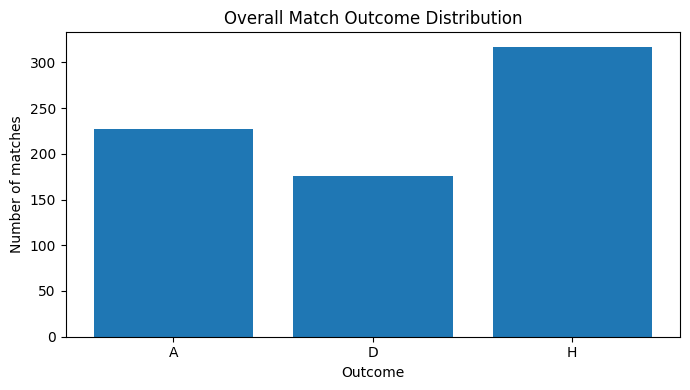

In [61]:
plt.figure(figsize=(7, 4))
plt.bar(outcome_counts.index, outcome_counts.values)
plt.title("Overall Match Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of matches")
plt.tight_layout()
plt.show()

**Outcome distribution by season**

In [62]:
outcome_by_season = (
    matches_df.groupby(["season", "result_1x2"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .sort_values("season")
)

outcome_by_season

result_1x2,season,A,D,H
0,2022,77,59,104
1,2023,71,63,106
2,2024,79,54,107


## 7. Team-level inspection

We check the number of unique teams and how often each team appears in the filtered dataset.

**Unique teams overview**

In [63]:
home_teams = set(matches_df["home_team_name"].dropna().unique())
away_teams = set(matches_df["away_team_name"].dropna().unique())
all_teams = sorted(home_teams.union(away_teams))

print("Unique home teams:", len(home_teams))
print("Unique away teams:", len(away_teams))
print("Unique teams overall:", len(all_teams))
all_teams[:15]

Unique home teams: 18
Unique away teams: 18
Unique teams overall: 18


['Baník Ostrava',
 'Bohemians 1905',
 'Dukla Praha',
 'FK Jablonec',
 'Hradec Králové',
 'Karviná',
 'Mlada Boleslav',
 'Pardubice',
 'Plzen',
 'Sigma Olomouc',
 'Slavia Praha',
 'Slovan Liberec',
 'Slovácko',
 'Sparta Praha',
 'Teplice']

**Match counts per team**

In [64]:
home_counts = matches_df["home_team_name"].value_counts().rename("home_matches")
away_counts = matches_df["away_team_name"].value_counts().rename("away_matches")

team_match_counts = pd.concat([home_counts, away_counts], axis=1).fillna(0)
team_match_counts["total_matches"] = team_match_counts["home_matches"] + team_match_counts["away_matches"]
team_match_counts = team_match_counts.sort_values("total_matches", ascending=False)

team_match_counts.head(15)

,home_matches,away_matches,total_matches
Plzen,45,45,90
Slovan Liberec,45,45,90
Mlada Boleslav,45,45,90
Slovácko,45,45,90
České Budějovice,45,45,90
Bohemians 1905,45,45,90
Slavia Praha,45,45,90
Sigma Olomouc,45,45,90
Sparta Praha,45,45,90
FK Jablonec,45,45,90


**Teams by season**

In [25]:
teams_by_season = (
    pd.concat([
        matches_df[["season", "home_team_name"]].rename(columns={"home_team_name": "team"}),
        matches_df[["season", "away_team_name"]].rename(columns={"away_team_name": "team"}),
    ], ignore_index=True)
    .drop_duplicates()
    .groupby("season")
    .size()
    .rename("n_teams")
    .reset_index()
    .sort_values("season")
)

teams_by_season

,season,n_teams
0,2022,18
1,2023,18
2,2024,18


## 8. Regular-season round inspection

After filtering to regular-season matches only, we derive a numeric round variable from the round label.

In [65]:
matches_df["round"].dropna().head(20)

0     Regular Season - 1
1     Regular Season - 1
2     Regular Season - 1
3     Regular Season - 1
4     Regular Season - 1
5     Regular Season - 1
6     Regular Season - 1
7     Regular Season - 1
8     Regular Season - 2
9     Regular Season - 2
10    Regular Season - 2
11    Regular Season - 2
12    Regular Season - 2
13    Regular Season - 2
14    Regular Season - 2
15    Regular Season - 2
16    Regular Season - 3
17    Regular Season - 3
18    Regular Season - 3
19    Regular Season - 3
Name: round, dtype: object

**Extract round number**

In [66]:
def extract_round_number(value):
    if pd.isna(value):
        return None
    match = re.search(r"(\d+)", str(value))
    return int(match.group(1)) if match else None

matches_df["round_number"] = matches_df["round"].apply(extract_round_number)
matches_df[["round", "round_number"]].head(20)

,round,round_number
0,Regular Season - 1,1
1,Regular Season - 1,1
2,Regular Season - 1,1
3,Regular Season - 1,1
4,Regular Season - 1,1
5,Regular Season - 1,1
6,Regular Season - 1,1
7,Regular Season - 1,1
8,Regular Season - 2,2
9,Regular Season - 2,2


**Round summary**

In [67]:
round_summary = (
    matches_df.groupby("season")
    .agg(
        min_round=("round_number", "min"),
        max_round=("round_number", "max"),
        missing_rounds=("round_number", lambda x: x.isna().sum()),
    )
    .reset_index()
    .sort_values("season")
)

round_summary

,season,min_round,max_round,missing_rounds
0,2022,1,30,0
1,2023,1,30,0
2,2024,1,30,0


## 9. Date and timeline inspection

We verify the date coverage and inspect the temporal distribution of regular-season matches.

In [68]:
print("Minimum date:", matches_df["date"].min())
print("Maximum date:", matches_df["date"].max())
print("Missing date values:", matches_df["date"].isna().sum())

Minimum date: 2022-07-30 14:00:00
Maximum date: 2025-04-19 14:00:00
Missing date values: 0


**Matches by month**

In [69]:
matches_by_month = (
    matches_df
    .assign(month=matches_df["date"].dt.to_period("M").astype(str))
    .groupby("month")
    .size()
    .rename("match_count")
    .reset_index()
)

matches_by_month.head(12)

,month,match_count
0,2022-07,8
1,2022-08,39
2,2022-09,24
3,2022-10,39
4,2022-11,18
5,2023-01,8
6,2023-02,32
7,2023-03,23
8,2023-04,49
9,2023-07,16


**Monthly timeline plot**

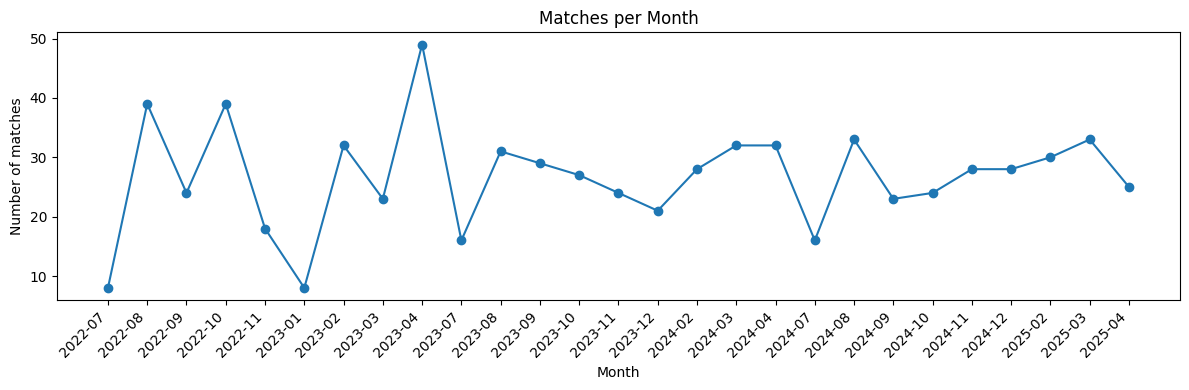

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(matches_by_month["month"], matches_by_month["match_count"], marker="o")
plt.title("Regular-Season Matches per Month")
plt.xlabel("Month")
plt.ylabel("Number of matches")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 10. Additional consistency checks

We verify:
- no team plays against itself,
- fixture IDs are unique after cleaning,
- the dataset can be safely sorted for downstream feature engineering.

**Same-team check**

In [71]:
same_team_df = matches_df[matches_df["home_team_id"] == matches_df["away_team_id"]]

print("Rows where home_team_id == away_team_id:", len(same_team_df))
same_team_df.head()

Rows where home_team_id == away_team_id: 0


,fixture_id,date,timestamp,status_long,status_short,league_id,league_name,season,round,home_team_id,home_team_name,away_team_id,away_team_name,home_goals,away_goals,halftime_home_goals,halftime_away_goals,result_1x2,goal_diff,total_goals,competition_phase,round_number


**Sort the dataset**

In [73]:
matches_df = matches_df.sort_values(["date", "fixture_id"]).reset_index(drop=True)
print("Dataset sorted successfully.")
matches_df.head()

Dataset sorted successfully.


,fixture_id,date,timestamp,status_long,status_short,league_id,league_name,season,round,home_team_id,home_team_name,away_team_id,away_team_name,home_goals,away_goals,halftime_home_goals,halftime_away_goals,result_1x2,goal_diff,total_goals,competition_phase,round_number
0,880111,2022-07-30 14:00:00,1659189600,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,603,Zlin,640,Mlada Boleslav,0,0,0,0,D,0,0,regular_season,1
1,880112,2022-07-30 14:00:00,1659189600,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,3733,Zbrojovka Brno,3719,Slovácko,2,2,2,1,D,0,4,regular_season,1
2,880114,2022-07-30 14:00:00,1659189600,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,3713,Baník Ostrava,2250,Sigma Olomouc,0,3,0,1,A,-3,3,regular_season,1
3,880107,2022-07-30 17:00:00,1659200400,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,3720,Teplice,567,Plzen,2,2,1,0,D,0,4,regular_season,1
4,880108,2022-07-31 14:00:00,1659276000,Match Finished,FT,345,Czech Liga,2022,Regular Season - 1,3724,Pardubice,3736,České Budějovice,0,2,0,1,A,-2,2,regular_season,1


**Final preview**

In [74]:
preview_cols = [
    "fixture_id",
    "date",
    "season",
    "round",
    "competition_phase",
    "round_number",
    "home_team_name",
    "away_team_name",
    "home_goals",
    "away_goals",
    "result_1x2",
]

matches_df[preview_cols].head(15)

,fixture_id,date,season,round,competition_phase,round_number,home_team_name,away_team_name,home_goals,away_goals,result_1x2
0,880111,2022-07-30 14:00:00,2022,Regular Season - 1,regular_season,1,Zlin,Mlada Boleslav,0,0,D
1,880112,2022-07-30 14:00:00,2022,Regular Season - 1,regular_season,1,Zbrojovka Brno,Slovácko,2,2,D
2,880114,2022-07-30 14:00:00,2022,Regular Season - 1,regular_season,1,Baník Ostrava,Sigma Olomouc,0,3,A
3,880107,2022-07-30 17:00:00,2022,Regular Season - 1,regular_season,1,Teplice,Plzen,2,2,D
4,880108,2022-07-31 14:00:00,2022,Regular Season - 1,regular_season,1,Pardubice,České Budějovice,0,2,A
5,880109,2022-07-31 14:00:00,2022,Regular Season - 1,regular_season,1,Hradec Králové,Slavia Praha,1,0,H
6,880113,2022-07-31 14:00:00,2022,Regular Season - 1,regular_season,1,FK Jablonec,Bohemians 1905,0,3,A
7,880110,2022-07-31 17:00:00,2022,Regular Season - 1,regular_season,1,Sparta Praha,Slovan Liberec,1,2,A
8,880117,2022-08-06 14:00:00,2022,Regular Season - 2,regular_season,2,Slovan Liberec,Teplice,5,1,H
9,880118,2022-08-06 14:00:00,2022,Regular Season - 2,regular_season,2,Plzen,Pardubice,2,1,H


## 11. Export summary tables and clean dataset

We save:
- the clean regular-season match dataset,
- summary tables for later reporting.

**Save summary tables**

In [75]:
save_csv(
    missing_df.reset_index().rename(columns={"index": "column"}),
    TABLES_DIR / "missing_values_summary.csv",
    index=False,
)

save_csv(
    outcome_counts.rename_axis("result").reset_index(name="count"),
    TABLES_DIR / "outcome_distribution.csv",
    index=False,
)

save_csv(
    matches_per_season,
    TABLES_DIR / "matches_per_season.csv",
    index=False,
)

save_csv(
    team_match_counts.reset_index().rename(columns={"index": "team_name"}),
    TABLES_DIR / "team_match_counts.csv",
    index=False,
)

save_csv(
    phase_by_season_full,
    TABLES_DIR / "competition_phase_by_season.csv",
    index=False,
)

print("Summary tables saved to outputs/tables/")

Summary tables saved to outputs/tables/


**Save clean regular-season dataset**

In [76]:
output_path = league_interim_root / "matches_regular_season_clean.csv"
save_csv(matches_df, output_path, index=False)

print("Saved clean regular-season dataset:", output_path)

Saved clean regular-season dataset: C:\Users\cerve\Desktop\DP\football_prediction\data\interim\czech_liga\matches_regular_season_clean.csv


**Final summary**

In [79]:
summary = {
    "input_file": str(input_path),
    "output_file": str(output_path),
    "dataset_scope": "regular_season_only",
    "n_rows": len(matches_df),
    "n_columns": matches_df.shape[1],
    "n_teams": len(all_teams),
    "date_min": str(matches_df["date"].min()),
    "date_max": str(matches_df["date"].max()),
    "season_coverage": sorted(matches_df["season"].dropna().unique().tolist()),
    "class_distribution": outcome_counts.to_dict(),
}

summary

{'input_file': 'C:\\Users\\cerve\\Desktop\\DP\\football_prediction\\data\\interim\\czech_liga\\matches_all_seasons_raw.csv',
 'output_file': 'C:\\Users\\cerve\\Desktop\\DP\\football_prediction\\data\\interim\\czech_liga\\matches_regular_season_clean.csv',
 'dataset_scope': 'regular_season_only',
 'n_rows': 720,
 'n_columns': 22,
 'n_teams': 18,
 'date_min': '2022-07-30 14:00:00',
 'date_max': '2025-04-19 14:00:00',
 'season_coverage': [2022, 2023, 2024],
 'class_distribution': {'A': 227, 'D': 176, 'H': 317}}

## Notebook summary

This notebook:
- loaded the combined raw multi-season dataset,
- identified competition phases from round labels,
- filtered the data to **regular season matches only**,
- checked data quality and consistency,
- inspected season, team, round, and date coverage,
- exported a clean regular-season dataset for feature engineering.

## Modeling scope
The first version of the predictive pipeline is based on **regular season matches only** in order to preserve:
- a consistent 16-team competition structure,
- comparable round progression,
- and homogeneous match conditions across seasons.

## Next step
The next notebook (`01b_fixture_statistics_collection.ipynb` or `03_feature_engineering.ipynb`) will:
- either collect detailed fixture statistics,
- or start building rolling pre-match features from the clean regular-season dataset.